In [1]:
import torch
from torch import nn
from tqdm import tqdm
import copy
import torch.nn.functional as F

import sys, os
sys.path.append(os.path.abspath("../"))
import preprocessing
from preprocessing import NinaProDataset
import numpy as np

from helpers import *
from torch_models import NinaProClassifyCNN

import matplotlib.pyplot as plt


In [2]:
# Initialize Model and Dataset for training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

model = NinaProClassifyCNN(13).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

x_train, y_train, x_test, y_test, class_weights = preprocessing.multi_preprocess(exercise_number=1, path="../NinaProData")
batch_size = 100

train_data = NinaProDataset(x_train, y_train)
test_data = NinaProDataset(x_test, y_test)
train1_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test1_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)


loss_func = nn.CrossEntropyLoss()

Using cuda device


subject #[[1]]
exercise #[[1]]
0.0     351
5.0      58
3.0      53
1.0      50
8.0      44
6.0      43
12.0     42
4.0      41
10.0     39
2.0      37
7.0      36
9.0      35
11.0     35
Name: count, dtype: int64
0.0     908
3.0      30
1.0      26
10.0     25
12.0     23
5.0      22
4.0      18
6.0      17
7.0      17
9.0      17
2.0      16
8.0      16
11.0     15
Name: count, dtype: int64
subject #[[2]]
exercise #[[1]]
0.0     291
5.0      55
7.0      54
3.0      53
8.0      50
11.0     50
4.0      49
2.0      48
9.0      48
6.0      46
12.0     42
10.0     39
1.0      37
Name: count, dtype: int64
0.0     880
8.0      28
3.0      26
1.0      24
5.0      24
4.0      23
7.0      22
9.0      21
10.0     21
2.0      20
6.0      20
11.0     18
12.0     18
Name: count, dtype: int64
subject #[[3]]
exercise #[[1]]
0.0     339
2.0      54
3.0      52
5.0      47
6.0      47
12.0     46
1.0      44
7.0      43
4.0      42
8.0      40
9.0      39
10.0     35
11.0     34
Name: count, dtype: int

In [3]:
# Train Model

print("Starting Training")
epochs = 60
model.train()

measures = train_base(
    model,
    train1_loader,
    device,
    optimizer,
    loss_func,
    epochs,
    accuracy_over_time=True,
    test=test1_loader
)
        

Starting Training


<function matplotlib.pyplot.show(close=None, block=None)>

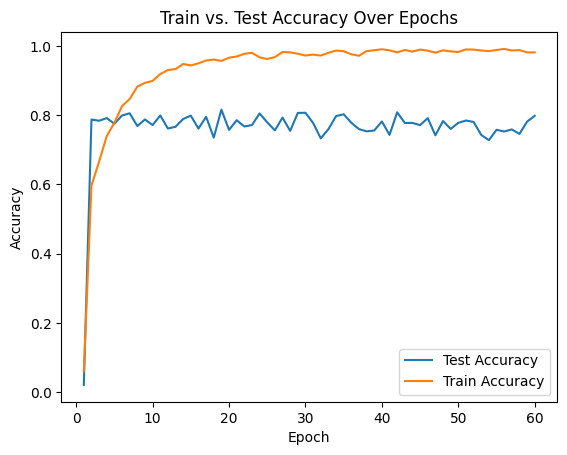

In [4]:
test_accs = measures[0]
train_accs = measures[1]

x_axis_epochs = range(1, len(measures[0]) + 1)
plt.plot(x_axis_epochs, test_accs, label="Test Accuracy")
plt.plot(x_axis_epochs, train_accs, label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs. Test Accuracy Over Epochs")
plt.legend()
plt.show

In [5]:
# Accuracy:
find_accuracy(model, test1_loader, device, loss_func)

0.7912794623621339

In [6]:

accs = multi_class_acc_measure(test1_loader, model, device, num_classes=13)
for i, a in enumerate(accs):
    print(f"Class {i}: {a.item():.3f}")

Class 0: 0.842
Class 1: 0.595
Class 2: 0.769
Class 3: 0.406
Class 4: 0.745
Class 5: 0.787
Class 6: 0.714
Class 7: 0.597
Class 8: 0.662
Class 9: 0.585
Class 10: 0.600
Class 11: 0.701
Class 12: 0.626


In [7]:
# CIL / LWF

x2_train, y2_train, x2_test, y2_test, class_weights_2 = preprocessing.multi_preprocess(2, "../NinaProData")

# Since resting is a massive portion of our dataset, remove all resting labels for now.

train2_data = NinaProDataset(x2_train, y2_train)
test2_data = NinaProDataset(x2_test, y2_test)

batch_size = 100
train2_loader = torch.utils.data.DataLoader(train2_data, batch_size=batch_size, shuffle=True)
test2_loader = torch.utils.data.DataLoader(test2_data, batch_size=batch_size, shuffle=False)

num_new_classes = len(np.unique(y2_train))

student = copy.deepcopy(model).to(device)
student = expand_classifier(student, new_size=num_new_classes, device=device)
student = student.to(device)



subject #[[1]]
exercise #[[2]]


0.0     488
17.0     59
9.0      50
12.0     50
1.0      49
6.0      47
16.0     47
13.0     46
2.0      45
4.0      45
7.0      43
3.0      42
10.0     41
8.0      39
5.0      36
11.0     36
15.0     34
14.0     30
Name: count, dtype: int64
0.0     1300
6.0       26
17.0      26
3.0       22
12.0      22
16.0      21
10.0      20
2.0       19
7.0       19
8.0       19
9.0       19
11.0      19
15.0      19
1.0       18
13.0      17
5.0       15
4.0       14
14.0      11
Name: count, dtype: int64
subject #[[2]]
exercise #[[2]]
0.0     357
1.0      63
17.0     59
11.0     57
16.0     56
2.0      55
4.0      55
10.0     54
7.0      53
3.0      52
9.0      50
13.0     49
5.0      47
6.0      46
12.0     45
14.0     44
8.0      42
15.0     42
Name: count, dtype: int64
0.0     1259
1.0       27
11.0      25
17.0      25
4.0       23
9.0       23
13.0      23
16.0      23
2.0       22
10.0      21
14.0      21
3.0       20
5.0       20
7.0       20
6.0       18
12.0      18
8.0       17
15.0

In [8]:
student = student.to(device)
student.train()

optimizer = torch.optim.Adam(student.parameters(), lr = 0.001)
epochs = 1000
T = 4
alpha_kd = .9

task0_accs = []
task1_accs = []

for epoch in range(epochs):
    # if epoch%10 == 0 or epoch < 5: find_accuracy(student, test2_loader)
    pbar = tqdm(train2_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    task0_accs.append(find_accuracy(student, test1_loader, device, loss_func))
    task1_accs.append(find_accuracy(student, train2_loader, device, loss_func, offset=13))
    for emg, labels in pbar:
        emg = emg.to(device)
        labels = labels.to(device)
        logits_stud_new = student(emg)
        loss_stud_new = loss_func(logits_stud_new[:, 13:], labels)
        
        with torch.no_grad():
            logits_teach = model(emg)
            loss_teach = F.softmax(logits_teach/T, dim = 1)
        loss_stud_old = F.log_softmax(logits_stud_new[:, :13]/T, dim=1)
        loss_old = F.kl_div(loss_stud_old, loss_teach, reduction = "batchmean") * (T**2)
        
        loss = (1-alpha_kd) * loss_stud_new + alpha_kd * loss_old
        optimizer.zero_grad()
                
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=loss.item())

In [9]:
import json
with open('../graphs/accuracy_data_base_nodrop_post_cl_point9kd_1000epochs.json', 'w') as file:
    json.dump((task0_accs, task1_accs), file)

<function matplotlib.pyplot.show(close=None, block=None)>

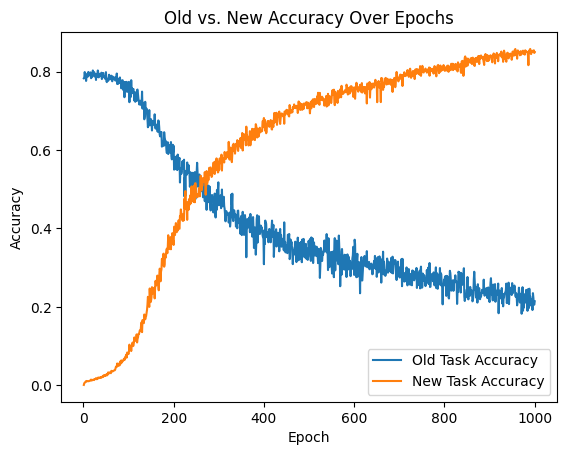

In [10]:


x_axis_epochs = range(1, len(task0_accs) + 1)
plt.plot(x_axis_epochs, task0_accs, label="Old Task Accuracy")
plt.plot(x_axis_epochs, task1_accs, label="New Task Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Old vs. New Accuracy Over Epochs")
plt.legend()
plt.show

In [11]:
print(f"Accuracy for old task")
find_accuracy(student, test1_loader)
print(f"Accuracy for new task")
find_accuracy(student, test2_loader, offset=12)

Accuracy for old task


TypeError: find_accuracy() missing 2 required positional arguments: 'device' and 'loss_func'